#                                               **MINI DATA DOCUMENT (MDD)**


# *Titanic Survival Analysis*

Author: Atul Dwivedi

Date: 28 February 2026

Dataset: Titanic passenger manifest (891 rows, 12 cols) — Titanic-Dataset.csv

Data Source: Titanic dataset (public Kaggle dataset).


## 1. Introduction

This project performs Exploratory Data Analysis (EDA) on the Titanic passenger dataset to understand what factors influenced survival during the disaster.

The dataset contains demographic and travel details of passengers such as age, gender, ticket class, fare paid, and family members onboard.

The purpose of this analysis is to determine whether survival was random or influenced by passenger characteristics.

## 2. Objective

To explore patterns and relationships in passenger characteristics and determine which factors most strongly influenced survival probability using exploratory data analysis.

### Main questions:

- Did gender influence survival?

- Did passenger class (Pclass) affect survival?

- Did younger passengers (children) have higher survival?

- Did travelling alone reduce survival chances?
  
- Did fare (wealth proxy) correlate with survival?

- Did interaction between gender and class influence survival?

## 3. Table of Contents

1. Data loading and preview  
2. Data understanding & missing values  
3. Data cleaning  
4. Baseline survival rate  
5. Gender analysis  
6. Passenger class analysis
7. Fare (wealth proxy) analysis  
8. Outlier detection  
9. Feature engineering  
10. Age group analysis  
11. Family & alone analysis  
12. Family size analysis  
13. Combined effect (Sex × Class) — shown by faceted barplots and pivot table  
14. Correlation analysis  
15. Final conclusion  

## 4. Dataset Description

The dataset contains 891 passenger records and 12 features:

### Feature	                  Description
PassengerId	:                Unique passenger number

Survived :                   Survival (0 = No, 1 = Yes)

Pclass :                     Passenger class (1 = High, 3 = Low)

Name :                       Passenger name

Sex :                        Gender

Age :                        Passenger age

SibSp :                      Siblings/Spouse onboard

Parch :                      Parents/Children onboard

Ticket :                     Ticket number

Fare :                       Ticket price

Cabin :                      Cabin number

Embarked :                   Boarding port

## 5. Tools Used

- Python

- Pandas

- Matplotlib

- Seaborn

- Jupyter Notebook

## 6. Data Understanding

Initial inspection of the dataset was done using:

- .shape

- .info()

- .describe()

- .isnull().sum()

This helped identify missing values and data types.

## 7. Data Cleaning

The following steps were performed:

### Cabin Column

- Contains large number of missing values

- Removed from datasetRemoved from dataset

### Embarked Column

- Few missing values

- Filled using most frequent value (mode)

### Age Column

- Missing values present

- Filled using median age based on passenger class and gender

**Reason** : Different passenger groups have different age distributions. So, we use median instead of mean because age may contain outliers.

## 8.  Outlier detection & policy

- Boxplots were used to inspect numeric columns.

- **Fare** shows high-value outliers (very expensive tickets) which represent genuine first-class / luxury fares. These outliers were **retained** because they are real observations and are important socio-economic signals.

- **Age** did not show problematic extremes after imputation.

## 9. Feature Engineering

New features were created to improve analysis:

### FamilySize

= SibSp + Parch + 1

Represents number of family members travelling together

### IsAlone

Indicates whether passenger was travelling alone

**Purpose**: To understand impact of family dependency on survival.

## 10. Analysis plan (what was plotted & why)

- Baseline survival rate (countplot) to set context.

- Survival vs `Sex` (barplot) — to show gender effect.  

- Survival vs `Pclass` (barplot) — to show socio-economic effect.  

- Fare distribution (boxplot) and survival-by-fare-group (barplot) — fare as wealth proxy.  

- Feature-based checks: `FamilySize`, `IsAlone`.  

- Age distribution with survival overlay and `AgeGroup` barplot.  

- Combined visual analysis: Show interaction between Sex and Pclass using faceted barplots (Sex-split counts / survival bars) and a small pivot-table of survival means (Sex × Pclass). These simpler, annotated visuals demonstrate the same interaction pattern (first-class females highest, third-class males lowest) without advanced statistical plots.

- Correlation heatmap for numeric variables to confirm relationships.

## Key visuals (to include in slides)

1. Survival rate by Sex (barplot)
3. Survival rate by Pclass (barplot)  
4. Survival-by-FareGroup (barplot) and Fare boxplot (context)  
5. Combined effect evidence: faceted barplots (Sex × Pclass) and a pivot table showing survival probabilities — these replace the heatmap and pointplot.  
6. Correlation heatmap (numeric features)

## 12. Key Findings

- **Gender**: Females had a substantially higher survival probability than males (clear in barplot).  

- **Class**: First-class passengers show higher survival than second and third class.  

- **Combined effect**: The Sex × Pclass heatmap shows first-class females with the highest survival and third-class males with the lowes the strongest combined pattern.

- **Age**: Younger passengers (children) show relatively higher survival — consistent with prioritized evacuation for children.  

- **Wealth proxy (Fare)**: Higher fares correlate with higher survival; we retained high-fare outliers because they are real and informative.  

- **Family vs Alone**: Passengers travelling alone were generally less likely to survive than those with family.

-  Small families (2–4 members) had the highest survival probability

-  Interaction effect shows evacuation priority hierarchy (female + upper class)

## 13. Limitations

- Observational dataset — we report associations, not causation.  

- `Cabin` missingness prevents deck-level or direct lifeboat-access analysis.  

- Imputation (Age) and grouping choices (AgeGroup, FareGroup) influence detailed numbers (but not the high-level patterns).  

- Grouping variables (AgeGroup, FareGroup) simplify reality and may hide fine-grained patterns.

## 14. Final takeaway

Survival on the Titanic was **structured by social and accessibility factors** — gender and socio-economic class (and their interaction) were the dominant influences, with family presence and age also important. The disaster reflected social priorities and ship layout rather than random survival chances.

# Titanic Survival Analysis

### Objective
**To understand what factors influenced survival during the Titanic disaster using Exploratory Data Analysis.**

### Key Question
**Was survival random, or affected by passenger characteristics like gender, class and family?**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("Titanic-Dataset.csv")

## <a id="load"></a>Data Load & Preview

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### **Insight**

**We previewed raw data and confirmed the key columns available for analysis: `Survived`, `Pclass`, `Sex`, `Age`, `Fare`, `SibSp`, `Parch`, `Embarked`.**

## <a id="info"></a>Dataset Info & Summary Statistics

In [4]:
df.shape

(891, 12)

In [5]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


### **Insight**

**Shape and summary statistics help us find missing values and skewed features (Age missing; Fare skewed; Cabin mostly missing).**


## Missing Values

In [8]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### **Insight**

**Missing values: Age (many), Cabin (lots), Embarked (2). This guides our cleaning plan.**

## <a id="cleaning"></a>Data Cleaning

In [9]:
# drop cabin (sparse)
df.drop(columns = 'Cabin', inplace = True)

In [10]:
# fill Embarked and Age safely (no SettingWithCopyWarning)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [11]:
# Impute Age by Pclass and Sex median (keeps group structure)
df['Age'] = df['Age'].fillna(df.groupby(['Pclass','Sex'])['Age'].transform('median'))

### **Insight**

**Cleaning decisions: Cabin removed due to >70% missing; Embarked filled with the mode; Age imputed using median within passenger class and gender groups.**

## Overall Survival Rate

First, we check the proportion of passengers who survived.

In [12]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

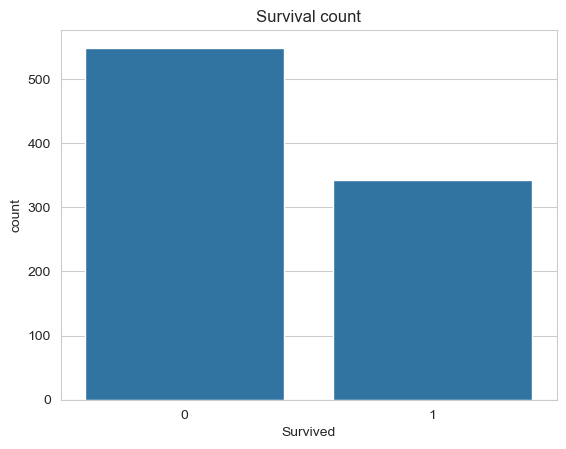

In [13]:
sns.countplot(x = 'Survived', data = df)
plt.title('Survival count')
plt.show()

### **Insight**

**Baseline survival: about 38% survived (342/891). Since overall survival rate is ~38%, any subgroup above this value performed better than the average passenger.**


### Does Gender Affect Survival?

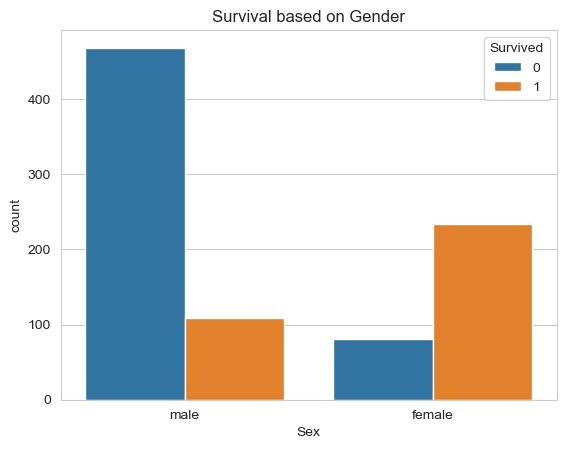

In [14]:
sns.countplot(x = 'Sex',hue = 'Survived', data = df)
plt.title('Survival based on Gender')
plt.show()

In [15]:
df.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

### **Insight**

**Females survived at a much higher rate ~74% than males ~19%.**

### Does Socioeconomic Status Affect Survival?

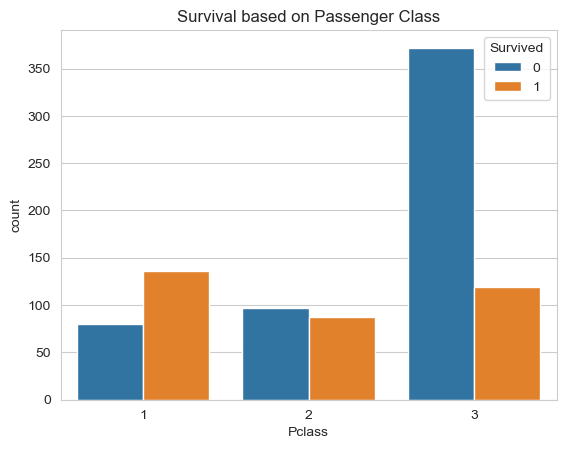

In [16]:
sns.countplot(x = 'Pclass', hue = 'Survived', data = df)
plt.title('Survival based on Passenger Class')
plt.show()

In [17]:
df.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

### **Insight**

**Survival rates by class: 1st ~63%, 2nd ~47%, 3rd ~24% — clear socioeconomic effect.The imbalance confirms the dataset represents a majority of non-survivors — making survival a minority outcome.**

## Outlier Detection

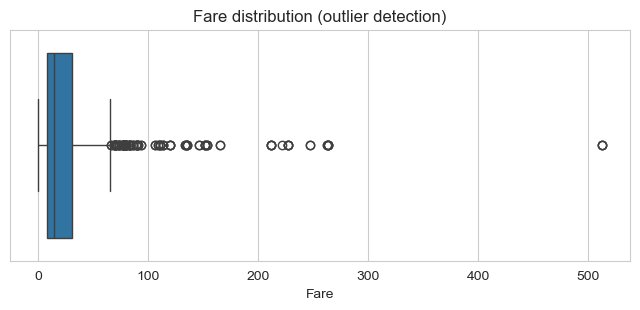

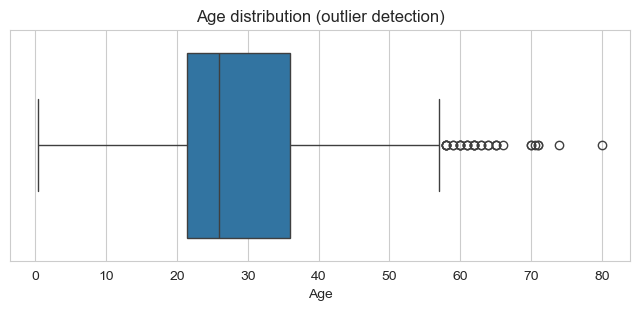

In [31]:
# Outlier detection: Fare and Age
plt.figure(figsize=(8,3))
sns.boxplot(x=df['Fare'])
plt.title("Fare distribution (outlier detection)")
plt.show()

plt.figure(figsize=(8,3))
sns.boxplot(x=df['Age'])
plt.title("Age distribution (outlier detection)")
plt.show()

### **Insight:** 
**Fare shows high-value outliers (very expensive tickets). These are real first-class fares and are retained because they carry meaningful socio-economic signal. Outliers were retained because removing them would bias socio-economic interpretation.**

*After inspecting distributions and confirming fare contains meaningful high values, we create derived features to better represent passenger social structure and dependency.*

## <a id="features"></a>Feature Engineering

In [33]:
# Family Size
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Alone passenger
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# Age groups
df['AgeGroup'] = pd.cut(df['Age'],
                        bins=[0,12,18,60,100],
                        labels=['Child','Teen','Adult','Senior'])

# Fare groups
df['FareGroup'] = pd.qcut(df['Fare'], 3, labels=['Low','Medium','High'])

df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone,AgeGroup,FareGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,0,Adult,Low
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,0,Adult,High
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,1,Adult,Low
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,0,Adult,High
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,1,Adult,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,1,1,Adult,Medium
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,1,1,Adult,High
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,21.5,1,2,W./C. 6607,23.4500,S,4,0,Adult,Medium
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,1,1,Adult,High


### Did Ticket Price Influence Survival?

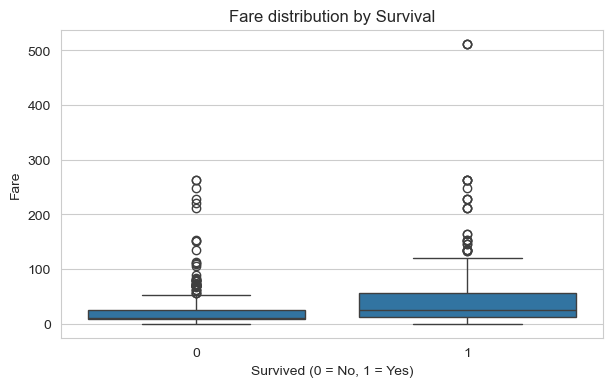

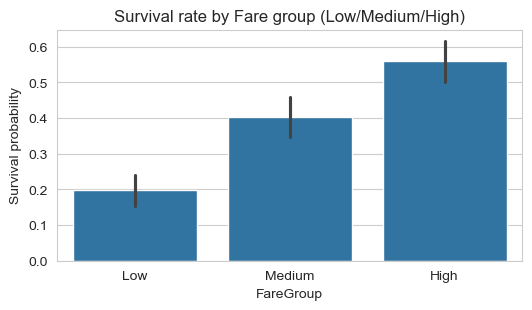

In [20]:
# Numeric Fare distribution by survival (boxplot)
plt.figure(figsize=(7,4))
sns.boxplot(x='Survived', y='Fare', data=df)
plt.title("Fare distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Fare")
plt.show()

# Survival rate by FareGroup (barplot)
plt.figure(figsize=(6,3))
sns.barplot(x='FareGroup', y='Survived', data=df, estimator=np.mean)
plt.title("Survival rate by Fare group (Low/Medium/High)")
plt.ylabel("Survival probability")
plt.show()

### **Insight**

**Survivors show a higher median fare and wider distribution, suggesting wealth increased evacuation access.**

## Survival by Age Group

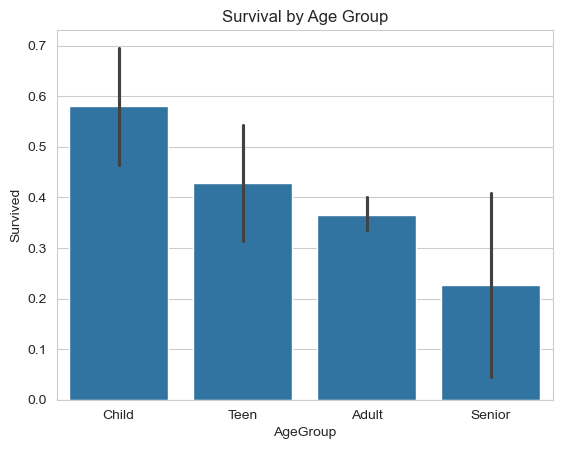

In [21]:
sns.barplot(x='AgeGroup', y='Survived', data=df)
plt.title("Survival by Age Group")
plt.show()

In [22]:
df.groupby('AgeGroup', observed=True)['Survived'].mean()

AgeGroup
Child     0.579710
Teen      0.428571
Adult     0.365753
Senior    0.227273
Name: Survived, dtype: float64

### **Insight**

**Survival by AgeGroup (Child > Teen > Adult > Senior) — Survival probability decreases with increasing age group.**

## <a id="family"></a>Survival Probability by Family Presence

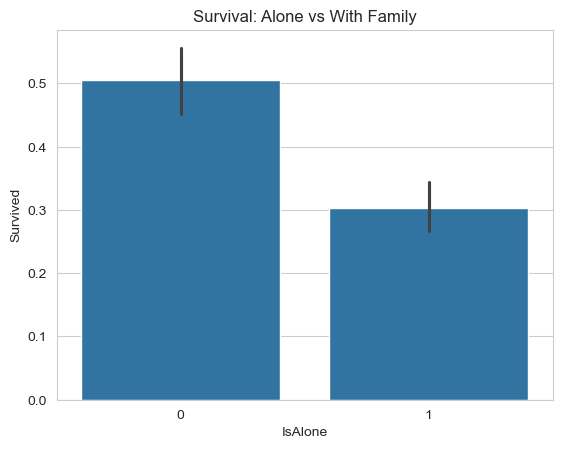

In [23]:
sns.barplot(x='IsAlone', y='Survived', data=df)
plt.title("Survival: Alone vs With Family")
plt.show()

In [24]:
df.groupby('IsAlone')['Survived'].mean()

IsAlone
0    0.505650
1    0.303538
Name: Survived, dtype: float64

### **Insight**

**Passengers travelling alone had a lower survival rate ~30% vs those with family ~50%.**

## Family Size & Survival

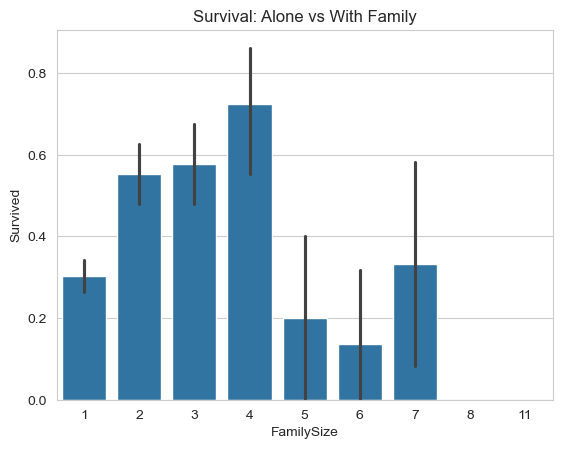

In [25]:
sns.barplot(x='FamilySize', y='Survived', data=df)
plt.title("Survival: Alone vs With Family")
plt.show()

In [26]:
df.groupby('FamilySize')['Survived'].mean()

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

### **Insight**

**Family size shows interesting peaks: small families (2–4) had higher survival than some larger groups — very large groups may have coordination issues.**

## Combined Effect: Gender × Class

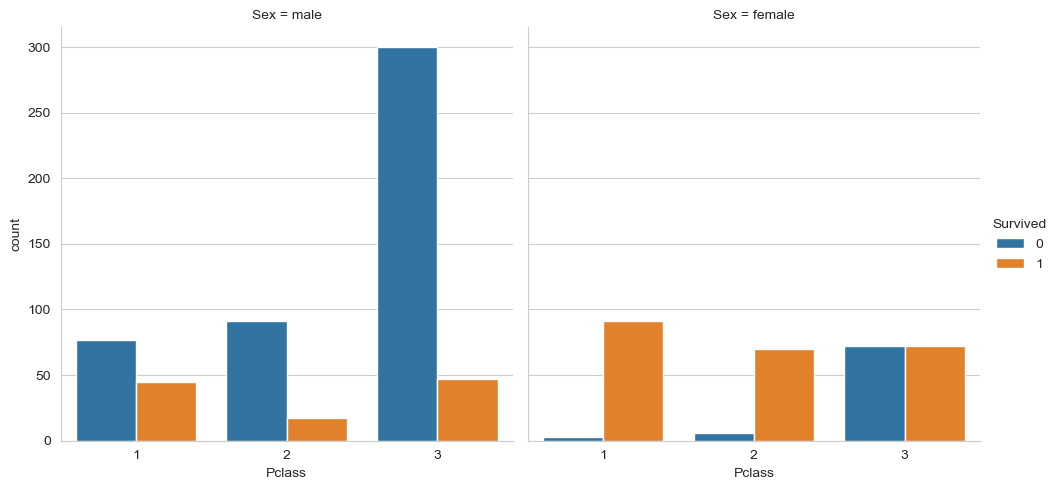

In [27]:
sns.catplot(x = 'Pclass', hue = 'Survived', col = 'Sex', data = df, kind = 'count')

### **Insight**

**Combining sex and class demonstrates a hierarchical evacuation pattern. (e.g., 1st-class females highest survival).**

## <a id="corr"></a>Correlation Matrix

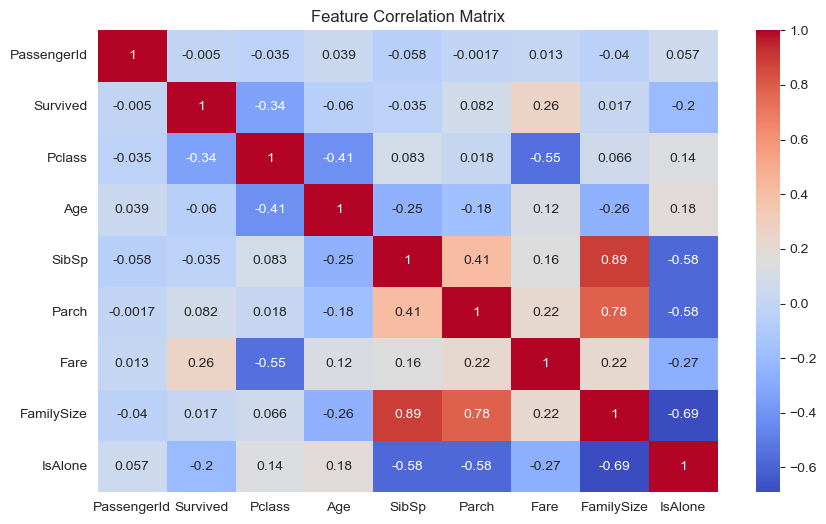

In [28]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

### **Insight**

**Pclass negatively correlates with survival while Fare positively correlates, reinforcing the socio-economic explanation. FamilySize and IsAlone behave as expected because they are mathematically related.**

# Final Conclusion

Survival on the Titanic was not random but structured by evacuation priority and ship accessibility.

The strongest determinant was gender, followed by **passenger class**.
Women in higher classes had extremely high survival probability, while third-class men had the lowest.

**Additional patterns refined this hierarchy:**

- Children were prioritized over adults and seniors

- Small families survived more than individuals or large groups

- Higher ticket fare (wealth proxy) increased survival likelihood

These patterns collectively indicate survival depended on social priority and physical access to lifeboats rather than chance.